In [5]:
# Cell 1 — Imports
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings("ignore")

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import pyswarms as ps

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (balanced_accuracy_score,
    precision_recall_curve)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shared.config import *
from shared.metrics import (ids_evaluate, tune_threshold,
                             tune_threshold_proba)
from shared.plots import plot_metrics_bar, plot_frontier

print("Imports OK")

Config loaded successfully
Imports OK


In [4]:
import sys
!{sys.executable} -m pip install --upgrade imbalanced-learn scikit-learn

  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]


In [2]:
import sys
!{sys.executable} -m pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyswarms]━━ 1/2 [pyswarms]


In [6]:
# Cell 2 — Load splits + previous results
with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)

X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

with open("models/ml/all_results.pkl", "rb") as f:
    all_results = pickle.load(f)

print("Data and previous results loaded")

Data and previous results loaded


In [7]:
# Cell 3 — Optuna Bayesian HPO
def objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int(
                             "n_estimators", 200, 600),
        "max_depth"       : trial.suggest_int(
                             "max_depth", 4, 10),
        "learning_rate"   : trial.suggest_float(
                             "learning_rate",
                             0.01, 0.1, log=True),
        "subsample"       : trial.suggest_float(
                             "subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float(
                             "colsample_bytree", 0.6, 1.0),
        "tree_method"     : "hist",
        "device"          : "cpu",
        "eval_metric"     : "logloss",
        "random_state"    : RANDOM_STATE
    }
    clf = XGBClassifier(**params)
    clf.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=30,
            verbose=False)
    th     = tune_threshold(clf, X_val, y_val)
    proba  = clf.predict_proba(X_val)[:, 1]
    y_pred = (proba >= th).astype(int)
    return balanced_accuracy_score(y_val, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS,
               show_progress_bar=True)

print(f"Best params      : {study.best_params}")
print(f"Best Balanced Acc: {study.best_value:.4f}")

  0%|          | 0/30 [00:00<?, ?it/s]

Best params      : {'n_estimators': 474, 'max_depth': 9, 'learning_rate': 0.056255552001782144, 'subsample': 0.7275863095535869, 'colsample_bytree': 0.9243010254242655}
Best Balanced Acc: 0.9664


In [8]:
# Cell 4 — Train best_xgb
best_xgb = XGBClassifier(
    **study.best_params,
    tree_method="hist",
    device="cpu",
    random_state=RANDOM_STATE
)
best_xgb.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              early_stopping_rounds=50,
              verbose=False)

th_optuna   = tune_threshold(best_xgb, X_val, y_val)
proba_optuna = best_xgb.predict_proba(X_test)[:, 1]
y_pred_optuna = (proba_optuna >= th_optuna).astype(int)

optuna_m = ids_evaluate("XGBoost+Optuna", y_test.values,
                          proba_optuna, y_pred_optuna,
                          th_optuna)
print("Optuna XGBoost metrics:")
for k, v in optuna_m.items():
    print(f"  {k}: {v}")

with open("models/ml/best_xgb.pkl", "wb") as f:
    pickle.dump(best_xgb, f)
with open("models/ml/optuna_study.pkl", "wb") as f:
    pickle.dump(study, f)

Optuna XGBoost metrics:
  Model: XGBoost+Optuna
  Balanced Acc: 0.9661
  F1 Macro: 0.9666
  MCC: 0.9331
  Attack Recall: 0.9492
  Benign Recall: 0.983
  Attack Precision: 0.9521
  Benign Precision: 0.982
  FAR: 0.017
  FNR: 0.0508
  ROC-AUC: 0.9929
  PR-AUC: 0.987


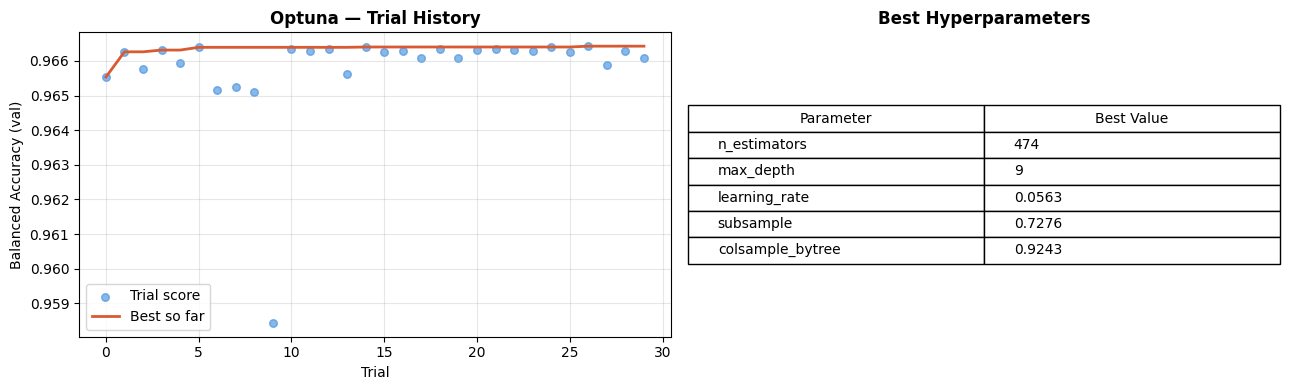

In [9]:
# Cell 5 — Optuna graphs
trial_nums  = [t.number for t in study.trials]
trial_vals  = [t.value  for t in study.trials]
best_so_far = [max(trial_vals[:i+1])
               for i in range(len(trial_vals))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(trial_nums, trial_vals, s=30,
                alpha=0.6, color="#378ADD",
                label="Trial score")
axes[0].plot(trial_nums, best_so_far,
             color="#D85A30", linewidth=2,
             label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Balanced Accuracy (val)")
axes[0].set_title("Optuna — Trial History",
                   fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

param_names = list(study.best_params.keys())
param_vals  = [str(round(v, 4))
               if isinstance(v, float) else str(v)
               for v in study.best_params.values()]
axes[1].axis("off")
table = axes[1].table(
    cellText=[[n, v] for n, v in
              zip(param_names, param_vals)],
    colLabels=["Parameter", "Best Value"],
    cellLoc="left", loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)
axes[1].set_title("Best Hyperparameters",
                   fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/graphs/03_optuna_history.png", dpi=150)
plt.show()

In [10]:
# Cell 6 — Feature Importance selection
importances   = best_xgb.feature_importances_
feature_names = X_train.columns.tolist()
sorted_idx    = np.argsort(importances)[::-1]
top_features  = [feature_names[i]
                 for i in sorted_idx[:PSO_TOP_N]]

X_train_fi = X_train[top_features]
X_val_fi   = X_val[top_features]
X_test_fi  = X_test[top_features]

xgb_fi = XGBClassifier(**study.best_params,
                         tree_method="hist",
                         device="cpu",
                         random_state=RANDOM_STATE)
xgb_fi.fit(X_train_fi, y_train,
            eval_set=[(X_val_fi, y_val)],
            early_stopping_rounds=50, verbose=False)

th_fi    = tune_threshold(xgb_fi, X_val_fi, y_val)
proba_fi = xgb_fi.predict_proba(X_test_fi)[:, 1]
fi_m     = ids_evaluate("Feat. Importance",
                          y_test.values, proba_fi,
                          (proba_fi >= th_fi).astype(int),
                          th_fi)
print("Feature Importance metrics:")
for k, v in fi_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_fi.pkl", "wb") as f:
    pickle.dump(xgb_fi, f)

Feature Importance metrics:
  Model: Feat. Importance
  Balanced Acc: 0.9657
  F1 Macro: 0.9656
  MCC: 0.9312
  Attack Recall: 0.9495
  Benign Recall: 0.9819
  Attack Precision: 0.949
  Benign Precision: 0.9821
  FAR: 0.0181
  FNR: 0.0505
  ROC-AUC: 0.9925
  PR-AUC: 0.9865


In [11]:
# Cell 7 — Univariate SelectKBest
selector = SelectKBest(score_func=f_classif, k=PSO_TOP_N)
selector.fit(X_train, y_train)

X_train_uni = selector.transform(X_train)
X_val_uni   = selector.transform(X_val)
X_test_uni  = selector.transform(X_test)

xgb_uni = XGBClassifier(**study.best_params,
                          tree_method="hist",
                          device="cpu",
                          random_state=RANDOM_STATE)
xgb_uni.fit(X_train_uni, y_train,
             eval_set=[(X_val_uni, y_val)],
             early_stopping_rounds=50, verbose=False)

th_uni    = tune_threshold(xgb_uni, X_val_uni, y_val)
proba_uni = xgb_uni.predict_proba(X_test_uni)[:, 1]
uni_m     = ids_evaluate("Univariate (KB)",
                          y_test.values, proba_uni,
                          (proba_uni >= th_uni).astype(int),
                          th_uni)
print("Univariate selection metrics:")
for k, v in uni_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_uni.pkl", "wb") as f:
    pickle.dump(xgb_uni, f)
with open("models/ml/selector_uni.pkl", "wb") as f:
    pickle.dump(selector, f)

Univariate selection metrics:
  Model: Univariate (KB)
  Balanced Acc: 0.9645
  F1 Macro: 0.9633
  MCC: 0.9266
  Attack Recall: 0.9496
  Benign Recall: 0.9793
  Attack Precision: 0.9423
  Benign Precision: 0.982
  FAR: 0.0207
  FNR: 0.0504
  ROC-AUC: 0.9913
  PR-AUC: 0.985


In [12]:
# Cell 8 — PCA
scaler_pca   = StandardScaler()
X_tr_pca_raw = scaler_pca.fit_transform(X_train)
X_va_pca_raw = scaler_pca.transform(X_val)
X_te_pca_raw = scaler_pca.transform(X_test)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_tr_pca_raw)
X_val_pca   = pca.transform(X_va_pca_raw)
X_test_pca  = pca.transform(X_te_pca_raw)

print(f"Original : {X_train.shape[1]} features")
print(f"PCA      : {pca.n_components_} components")
print(f"Variance : {pca.explained_variance_ratio_.sum():.4f}")

xgb_pca = XGBClassifier(**study.best_params,
                          tree_method="hist",
                          device="cpu",
                          random_state=RANDOM_STATE)
xgb_pca.fit(X_train_pca, y_train,
             eval_set=[(X_val_pca, y_val)],
             early_stopping_rounds=50, verbose=False)

th_pca    = tune_threshold(xgb_pca, X_val_pca, y_val)
proba_pca = xgb_pca.predict_proba(X_test_pca)[:, 1]
pca_m     = ids_evaluate("PCA",
                          y_test.values, proba_pca,
                          (proba_pca >= th_pca).astype(int),
                          th_pca)
print("PCA metrics:")
for k, v in pca_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_pca.pkl", "wb") as f:
    pickle.dump(xgb_pca, f)
with open("models/ml/pca_transformer.pkl", "wb") as f:
    pickle.dump((scaler_pca, pca), f)

Original : 78 features
PCA      : 24 components
Variance : 0.9535
PCA metrics:
  Model: PCA
  Balanced Acc: 0.9632
  F1 Macro: 0.961
  MCC: 0.922
  Attack Recall: 0.9495
  Benign Recall: 0.9768
  Attack Precision: 0.9358
  Benign Precision: 0.982
  FAR: 0.0232
  FNR: 0.0505
  ROC-AUC: 0.9915
  PR-AUC: 0.9851


In [13]:
# Cell 9 — PSO feature selection
rng      = np.random.RandomState(RANDOM_STATE)
idx_pso  = rng.choice(len(X_train), SAMPLE_PSO,
                        replace=False)
X_tr_pso = X_train.iloc[idx_pso].values
y_tr_pso = y_train.iloc[idx_pso].values
X_va_pso = X_val.values
y_va_pso = y_val.values
n_feat   = X_tr_pso.shape[1]

def pso_objective(particles):
    costs = []
    for particle in particles:
        mask = particle > 0.5
        if mask.sum() == 0:
            costs.append(1.0)
            continue
        clf = XGBClassifier(
            n_estimators=100, max_depth=5,
            tree_method="hist", device="cpu",
            random_state=RANDOM_STATE, verbosity=0
        )
        clf.fit(X_tr_pso[:, mask], y_tr_pso)
        proba_v = clf.predict_proba(
            X_va_pso[:, mask])[:, 1]
        th      = tune_threshold_proba(proba_v, y_va_pso)
        y_pred  = (proba_v >= th).astype(int)
        costs.append(1 - balanced_accuracy_score(
            y_va_pso, y_pred))
    return np.array(costs)

options   = {"c1": 0.5, "c2": 0.3, "w": 0.9}
optimizer = ps.single.GlobalBestPSO(
    n_particles=PSO_PARTICLES,
    dimensions=n_feat,
    options=options,
    bounds=(np.zeros(n_feat), np.ones(n_feat))
)
best_cost, best_pos = optimizer.optimize(
    pso_objective, iters=PSO_ITERS)

pso_mask     = best_pos > 0.5
pso_features = [f for f, s in
                zip(X_train.columns, pso_mask) if s]
print(f"PSO selected {pso_mask.sum()} / "
      f"{n_feat} features")

X_train_pso = X_train[pso_features]
X_val_pso   = X_val[pso_features]
X_test_pso  = X_test[pso_features]

xgb_pso = XGBClassifier(**study.best_params,
                          tree_method="hist",
                          device="cpu",
                          random_state=RANDOM_STATE)
xgb_pso.fit(X_train_pso, y_train,
             eval_set=[(X_val_pso, y_val)],
             early_stopping_rounds=50, verbose=False)

th_pso    = tune_threshold(xgb_pso, X_val_pso, y_val)
proba_pso = xgb_pso.predict_proba(X_test_pso)[:, 1]
pso_m     = ids_evaluate("PSO",
                          y_test.values, proba_pso,
                          (proba_pso >= th_pso).astype(int),
                          th_pso)
print("PSO metrics:")
for k, v in pso_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_pso.pkl", "wb") as f:
    pickle.dump(xgb_pso, f)
with open("models/ml/pso_features.pkl", "wb") as f:
    pickle.dump(pso_features, f)

2026-03-20 14:07:25,064 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|20/20, best_cost=0.0408
2026-03-20 14:13:36,146 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.040827967637691365, best pos: [0.96787204 0.2664555  0.77149472 0.60790771 0.8293712  0.25757494
 0.6736105  0.26854651 0.89718619 0.95735052 0.04596328 0.6850151
 0.91724013 0.73302015 0.22266958 0.95692097 0.02508284 0.22410488
 0.49424184 0.58878467 0.15010766 0.565132   0.01645976 0.59286944
 0.6989689  0.79725106 0.72109924 0.40125184 0.43212203 0.50043007
 0.81373216 0.21751155 0.20187715 0.16130932 0.82364087 0.56538689
 0.23666035 0.07204366 0.09687928 0.86876433 0.79692236 0.77695683
 0.76995776 0.98251888 0.60551562 0.57019863 0.52424055 0.05537445
 0.60642612 0.40664721 0.85322423 0.36735379 0.97357756 0.69959817
 0.19964803 0.73705671 0.19439029 0.53226138 0.71984635 0.97821889
 0.983300

PSO selected 47 / 78 features
PSO metrics:
  Model: PSO
  Balanced Acc: 0.9661
  F1 Macro: 0.9664
  MCC: 0.9329
  Attack Recall: 0.9493
  Benign Recall: 0.9829
  Attack Precision: 0.9517
  Benign Precision: 0.982
  FAR: 0.0171
  FNR: 0.0507
  ROC-AUC: 0.9927
  PR-AUC: 0.9868


In [15]:
# Cell 10 — SMOTE resampling
rng_sm   = np.random.RandomState(RANDOM_STATE)
idx_sm   = rng_sm.choice(len(X_train),
                           SAMPLE_SMOTE, replace=False)
X_sm_raw = X_train.iloc[idx_sm].values
y_sm_raw = y_train.iloc[idx_sm].values

print(f"Before SMOTE: {np.bincount(y_sm_raw)}")
smote    = SMOTE(random_state=RANDOM_STATE)
X_sm, y_sm = smote.fit_resample(X_sm_raw, y_sm_raw)
print(f"After  SMOTE: {np.bincount(y_sm)}")

xgb_smote = XGBClassifier(**study.best_params,
                            tree_method="hist",
                            device="cpu",
                            random_state=RANDOM_STATE)
xgb_smote.fit(X_sm, y_sm)
th_smote    = tune_threshold(xgb_smote, X_val, y_val)
proba_smote = xgb_smote.predict_proba(X_test)[:, 1]
smote_m     = ids_evaluate("SMOTE",
                             y_test.values, proba_smote,
                             (proba_smote >= th_smote)
                             .astype(int), th_smote)
print("SMOTE metrics:")
for k, v in smote_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_smote.pkl", "wb") as f:
    pickle.dump(xgb_smote, f)

Before SMOTE: [110705  39295]
After  SMOTE: [110705 110705]
SMOTE metrics:
  Model: SMOTE
  Balanced Acc: 0.9595
  F1 Macro: 0.9543
  MCC: 0.9089
  Attack Recall: 0.9495
  Benign Recall: 0.9695
  Attack Precision: 0.9171
  Benign Precision: 0.9818
  FAR: 0.0305
  FNR: 0.0505
  ROC-AUC: 0.9893
  PR-AUC: 0.9823


In [16]:
# Cell 11 — scale_pos_weight
n_benign = int((y_train == 0).sum())
n_attack = int((y_train == 1).sum())
spw      = n_benign / n_attack
print(f"scale_pos_weight: {spw:.4f}")

xgb_spw = XGBClassifier(
    **study.best_params,
    tree_method="hist",
    device="cpu",
    scale_pos_weight=spw,
    random_state=RANDOM_STATE
)
xgb_spw.fit(X_train, y_train,
             eval_set=[(X_val, y_val)],
             early_stopping_rounds=50,
             verbose=False)

th_spw    = tune_threshold(xgb_spw, X_val, y_val)
proba_spw = xgb_spw.predict_proba(X_test)[:, 1]
spw_m     = ids_evaluate("scale_pos_weight",
                          y_test.values, proba_spw,
                          (proba_spw >= th_spw).astype(int),
                          th_spw)
print("scale_pos_weight metrics:")
for k, v in spw_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_spw.pkl", "wb") as f:
    pickle.dump(xgb_spw, f)

scale_pos_weight: 2.8139
scale_pos_weight metrics:
  Model: scale_pos_weight
  Balanced Acc: 0.9661
  F1 Macro: 0.9663
  MCC: 0.9326
  Attack Recall: 0.9495
  Benign Recall: 0.9826
  Attack Precision: 0.951
  Benign Precision: 0.9821
  FAR: 0.0174
  FNR: 0.0505
  ROC-AUC: 0.9929
  PR-AUC: 0.987


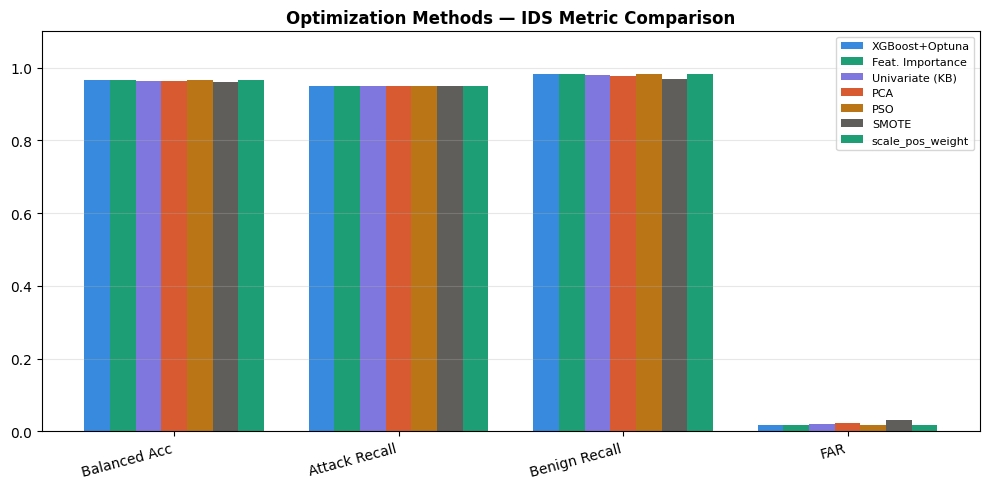

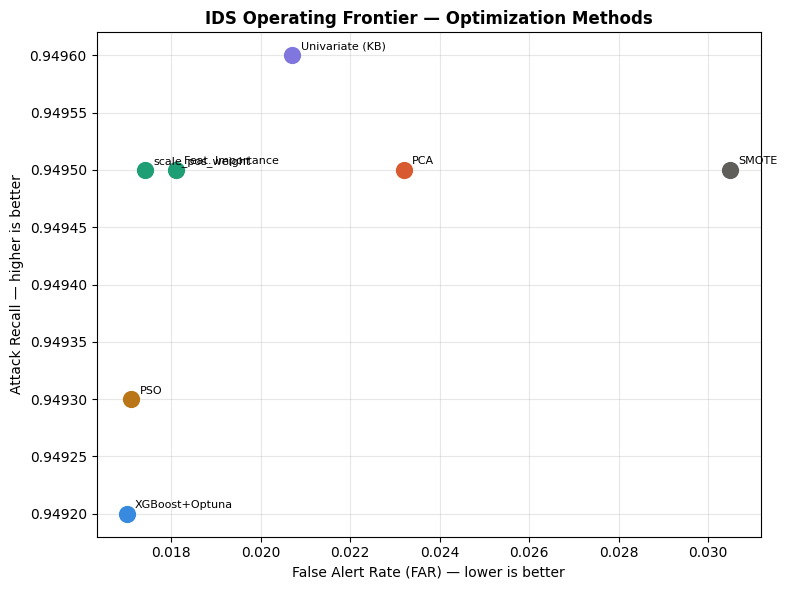

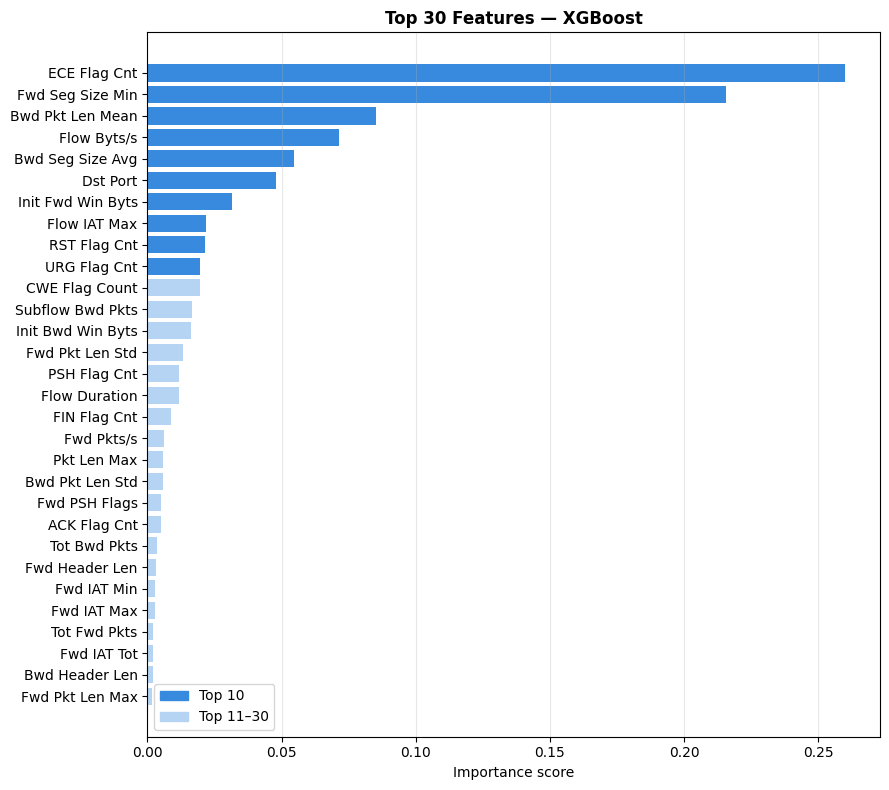

In [17]:
# Cell 12 — Optimization comparison graphs
opt_results = {
    "XGBoost+Optuna"   : optuna_m,
    "Feat. Importance" : fi_m,
    "Univariate (KB)"  : uni_m,
    "PCA"              : pca_m,
    "PSO"              : pso_m,
    "SMOTE"            : smote_m,
    "scale_pos_weight" : spw_m,
}

KEY = ["Balanced Acc","Attack Recall","Benign Recall","FAR"]
plot_metrics_bar(
    opt_results, KEY,
    title="Optimization Methods — IDS Metric Comparison",
    save_path="outputs/graphs/03_optimization_comparison.png"
)
plot_frontier(
    opt_results,
    title="IDS Operating Frontier — Optimization Methods",
    save_path="outputs/graphs/03_frontier_optimization.png"
)

# Feature importance chart
sorted_imp   = importances[sorted_idx[:PSO_TOP_N]]
sorted_names = [feature_names[i]
                for i in sorted_idx[:PSO_TOP_N]]

fig, ax = plt.subplots(figsize=(9, 8))
colors_fi = ["#378ADD" if i < 10
             else "#B5D4F4" for i in range(PSO_TOP_N)]
ax.barh(sorted_names[::-1], sorted_imp[::-1],
        color=colors_fi[::-1])
ax.set_xlabel("Importance score")
ax.set_title(f"Top {PSO_TOP_N} Features — XGBoost",
             fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
legend = [
    mpatches.Patch(color="#378ADD", label="Top 10"),
    mpatches.Patch(color="#B5D4F4", label="Top 11–30")
]
ax.legend(handles=legend)
plt.tight_layout()
plt.savefig("outputs/graphs/03_feature_importance.png",
            dpi=150)
plt.show()

In [18]:
# Cell 13 — Save all optimization results
opt_data = {
    "optuna_m"    : optuna_m,
    "fi_m"        : fi_m,
    "uni_m"       : uni_m,
    "pca_m"       : pca_m,
    "pso_m"       : pso_m,
    "smote_m"     : smote_m,
    "spw_m"       : spw_m,
    "study"       : study,
    "best_params" : study.best_params,
    "top_features": top_features,
    "pso_features": pso_features,
    "proba_optuna": proba_optuna,
}

with open("models/ml/opt_results.pkl", "wb") as f:
    pickle.dump(opt_data, f)

print("Notebook 03 complete — proceed to 04_deep_learning.ipynb")

Notebook 03 complete — proceed to 04_deep_learning.ipynb
